   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 6.2 MB/s eta 0:00:00
Mounted at /content/drive/
Found 101 ECG files and 89 lung files.

Subjects detected: ['alex', 'arthur', 'ben', 'crystal', 'jenny', 'jonah', 'mia', 'seth', 'sydney', 'tom', 'tyler', 'wally']

DESCRIPTIVE STATISTICS

CONTROL
Heart Rate (bpm)          mean=70.61  SD=9.49  n=12
HRV RMSSD (ms)            mean=109.35  SD=67.23  n=12
Resp. Rate (br/min)       mean=19.81  SD=6.78  n=5

DYSPNEA
Heart Rate (bpm)          mean=71.00  SD=9.77  n=11
HRV RMSSD (ms)            mean=110.85  SD=140.88  n=11
Resp. Rate (br/min)       mean=16.35  SD=3.56  n=7

APNEA
Heart Rate (bpm)          mean=68.57  SD=11.27  n=10
HRV RMSSD (ms)            mean=67.46  SD=83.24  n=10
Resp. Rate (br/min)       mean=0.00  SD=0.00  n=10

STATISTICAL TESTS

Heart Rate (bpm)
F = 0.172, p = 0.8426 (not significant)

HRV RMSSD (ms)
F = 0.612, p = 0.5490 (not significant)

Resp. Rate (br/min)
F = 64.371, p = 0.0000 (significant)
Tukey HSD pairwis

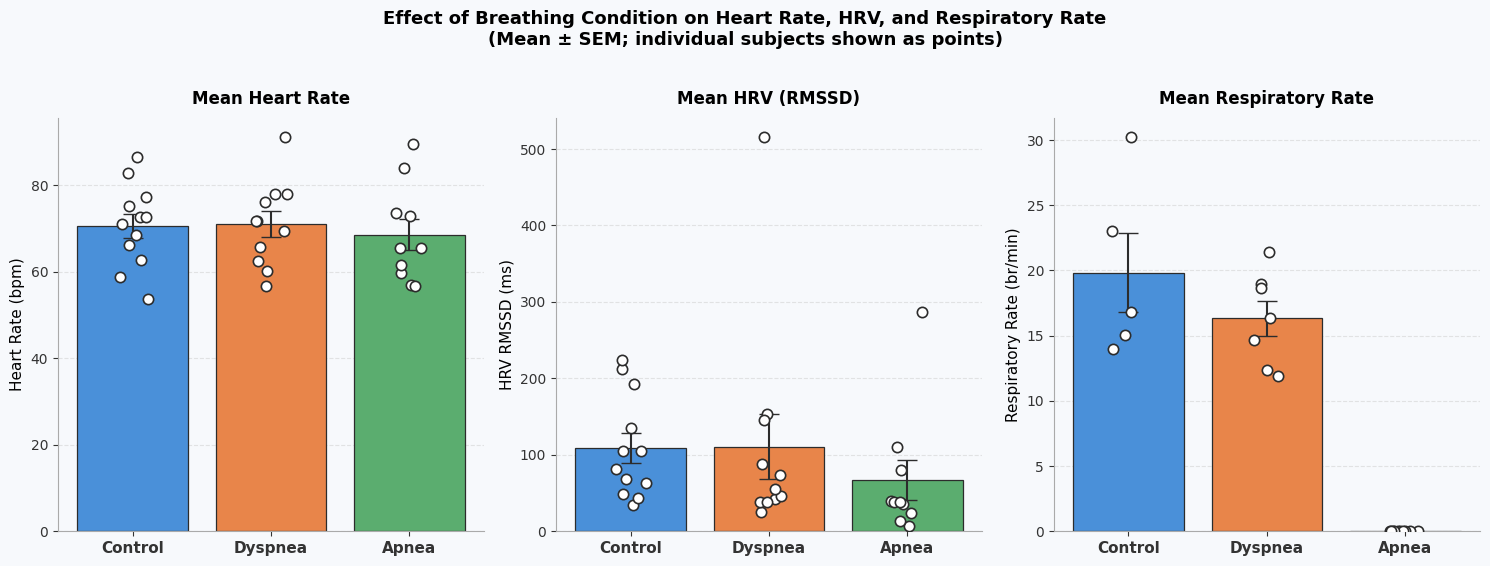

Figure saved

PEARSON CORRELATION: RSP Rate vs HR & HRV

RSP Rate vs Heart Rate
r = 0.021,  p = 0.9278  (not significant)

RSP Rate vs HRV (RMSSD)
r = 0.306,  p = 0.1768  (not significant)


NameError: name 'linregress' is not defined

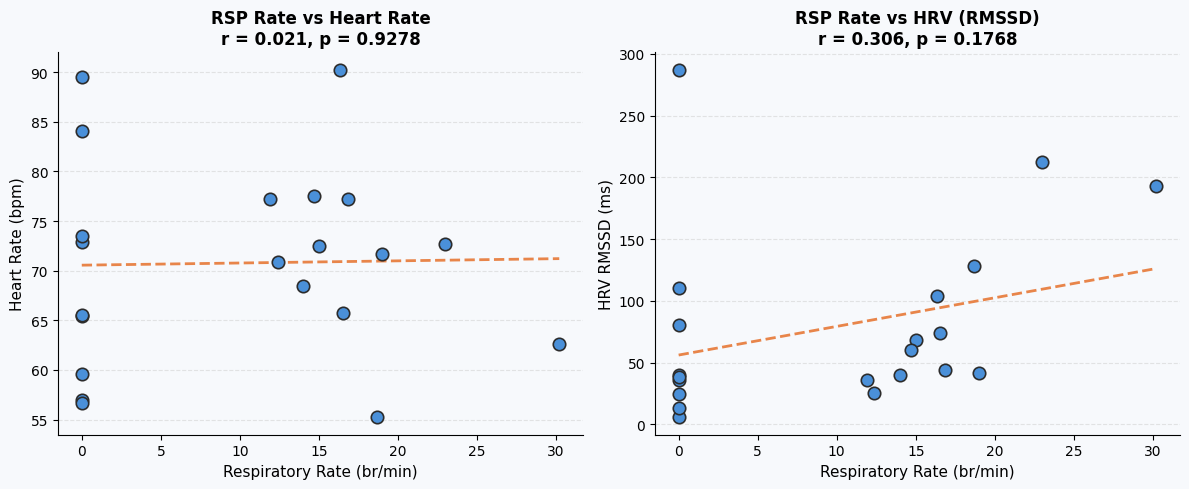

In [ ]:
# Move the trials to your drive folder since it doenst work from a shared folder then change DRIVE_FOLDER path to the folders path you placed the files in
# after that you should be able to run the program and it should work the way it should. There is one way anova, tukey test, pearson correlation test

!pip install neurokit2 -q

from google.colab import drive
drive.mount('/content/drive/')

import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import neurokit2 as nk
from scipy.stats import f_oneway, tukey_hsd

warnings.filterwarnings('ignore')

DRIVE_FOLDER = '/content/drive/MyDrive/test/'
SAMPLING_RATE = 200
CONDITIONS = ['control', 'dyspnea', 'apnea']
TRIALS = ['1', '2', '3']

def parse_filename(path):

    stem = os.path.splitext(os.path.basename(path))[0].lower()
    parts = stem.split('_')
    suffix = parts[-1].upper()
    trial = parts[-2]
    condition = parts[0].lower()
    subject = '_'.join(parts[1:-2])
    return condition, subject, trial, suffix

def process_ecg(path):

    try:
        df = pd.read_csv(path, sep='\t')
        ecg = df['ECG'].dropna().to_numpy(dtype=float)
        ecg = ecg[2000:]

        signals, info = nk.ecg_process(ecg, sampling_rate=SAMPLING_RATE)

        hr = float(np.nanmean(signals['ECG_Rate'].to_numpy()))

        r_peaks = info['ECG_R_Peaks']
        rr_ms = np.diff(r_peaks) / SAMPLING_RATE * 1000.0
        rmssd = float(np.sqrt(np.mean(np.diff(rr_ms) ** 2))) if len(rr_ms) > 1 else np.nan

        return hr, rmssd

    except Exception as e:
        print(f'ECG ERROR: {e}')
        return np.nan, np.nan

def process_lung(path):

    try:
        df = pd.read_csv(path, sep='\t')
        airflow = df['Air Flow'].dropna().to_numpy(dtype=float)
        airflow = airflow[2000:]

        signals, _ = nk.rsp_process(airflow, sampling_rate=SAMPLING_RATE)
        rsp_rate = float(np.nanmean(signals['RSP_Rate'].to_numpy()))
        return rsp_rate

    except Exception as e:
        print(f'LUNG ERROR: {e}')
        return np.nan

ecg_glob = glob.glob(f'{DRIVE_FOLDER}*_HR.xls') + glob.glob(f'{DRIVE_FOLDER}*_hr.xls')
lung_glob = glob.glob(f'{DRIVE_FOLDER}*_S.xls') + glob.glob(f'{DRIVE_FOLDER}*_s.xls')

print(f'Found {len(ecg_glob)} ECG files and {len(lung_glob)} lung files.\n')

ecg_raw = {}
lung_raw = {}
for f in sorted(ecg_glob):
    cond, subj, trial, _ = parse_filename(f)
    ecg_raw[(cond, subj, trial)] = process_ecg(f)

for f in sorted(lung_glob):
    cond, subj, trial, _ = parse_filename(f)

    if cond == 'apnea':
      lung_raw[(cond, subj, trial)] = 0
    else:
      lung_raw[(cond, subj, trial)] = process_lung(f)

subjects = sorted(set(subj for (_, subj, _) in ecg_raw))
print(f'Subjects detected: {subjects}')

summary = {c: {'HR': [], 'HRV_RMSSD': [], 'RSP_Rate': []} for c in CONDITIONS}

for cond in CONDITIONS:
    for subj in subjects:
        hrs, rmssds, rsps = [], [], []
        for trial in TRIALS:
            key = (cond, subj, trial)
            if key in ecg_raw:
                h, r = ecg_raw[key]
                if not np.isnan(h):
                    hrs.append(h)
                if not np.isnan(r):
                    rmssds.append(r)
            if key in lung_raw:
                rsp = lung_raw[key]
                if not np.isnan(rsp):
                    rsps.append(rsp)

        if hrs:
            summary[cond]['HR'].append(np.mean(hrs))
        if rmssds:
            summary[cond]['HRV_RMSSD'].append(np.mean(rmssds))
        if rsps:
            summary[cond]['RSP_Rate'].append(np.mean(rsps))

print('\nDESCRIPTIVE STATISTICS')

metric_labels = {'HR': 'Heart Rate (bpm)', 'HRV_RMSSD': 'HRV RMSSD (ms)', 'RSP_Rate': 'Resp. Rate (br/min)'}
for cond in CONDITIONS:
    print(f'\n{cond.upper()}')
    for metric, label in metric_labels.items():
        vals = summary[cond][metric]
        if vals:
            print(f'{label:<25s} mean={np.mean(vals):.2f}  SD={np.std(vals, ddof=1) if len(vals)>1 else 0:.2f}  n={len(vals)}')
        else:
            print(f'{label:<25s} no data')

print('\nSTATISTICAL TESTS')

for metric, label in metric_labels.items():
    groups = [summary[c][metric] for c in CONDITIONS if len(summary[c][metric]) >= 2]
    cond_labels = [c for c in CONDITIONS if len(summary[c][metric]) >= 2]
    print(f'\n{label}')
    if len(groups) >= 2:
        f_stat, p_val = f_oneway(*groups)
        sig = 'significant' if p_val < 0.05 else 'not significant'
        print(f'F = {f_stat:.3f}, p = {p_val:.4f} ({sig})')
        if p_val < 0.05 and len(groups) >= 3:
            result = tukey_hsd(*groups)
            print('Tukey HSD pairwise p-values:')
            for i, ci in enumerate(cond_labels):
                for j, cj in enumerate(cond_labels):
                    if j > i:
                        pv = result.pvalue[i, j]
                        print(f'{ci} vs {cj}: p = {pv:.4f}')
    else:
        print('Not enough groups for ANOVA.')

COLORS = {'control': '#4A90D9', 'dyspnea': '#E8854A', 'apnea': '#5BAD6F'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.patch.set_facecolor('#F7F9FC')

metrics_plot = [
    ('HR', 'Heart Rate (bpm)', 'Mean Heart Rate'),
    ('HRV_RMSSD', 'HRV RMSSD (ms)', 'Mean HRV (RMSSD)'),
    ('RSP_Rate', 'Respiratory Rate (br/min)', 'Mean Respiratory Rate'),
]

for ax, (metric, ylabel, title) in zip(axes, metrics_plot):
    ax.set_facecolor('#F7F9FC')
    means = []
    sems = []
    colors = []
    valid_conds = []

    for cond in CONDITIONS:
        vals = summary[cond][metric]
        if vals:
            means.append(np.mean(vals))
            sems.append(np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0)
            colors.append(COLORS[cond])
            valid_conds.append(cond.capitalize())

    x = np.arange(len(valid_conds))
    bars = ax.bar(x, means, yerr=sems, capsize=7,
                  color=colors, edgecolor='#2C2C2C', linewidth=0.9,
                  error_kw=dict(elinewidth=1.5, ecolor='#2C2C2C'))

    for i, cond in enumerate(CONDITIONS):
        if cond not in [c.lower() for c in valid_conds]:
            continue
        xi = [c.lower() for c in valid_conds].index(cond)
        vals = summary[cond][metric]
        jitter = np.random.uniform(-0.12, 0.12, len(vals))
        ax.scatter(xi + jitter, vals, color='white', edgecolors='#2C2C2C',
                   s=55, zorder=5, linewidth=1.2)

    ax.set_xticks(x)
    ax.set_xticklabels(valid_conds, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#AAAAAA')
    ax.tick_params(colors='#333333')
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')
    ax.set_axisbelow(True)

fig.suptitle(
    'Effect of Breathing Condition on Heart Rate, HRV, and Respiratory Rate\n'
    '(Mean ± SEM; individual subjects shown as points)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('breathing_conditions_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved')

# Correlation: Respiratory Rate vs HR and HRV

from scipy.stats import pearsonr

print("\nPEARSON CORRELATION: RSP Rate vs HR & HRV")

rsp_all, hr_all, hrv_all = [], [], []

for cond in CONDITIONS:
    for subj in subjects:
        rsp_vals, hr_vals, hrv_vals = [], [], []
        for trial in TRIALS:
            key = (cond, subj, trial)
            if key in lung_raw and key in ecg_raw:
                rsp = lung_raw[key]
                hr, hrv = ecg_raw[key]
                if not np.isnan(rsp) and not np.isnan(hr):
                    rsp_vals.append(rsp)
                    hr_vals.append(hr)
                if not np.isnan(rsp) and not np.isnan(hrv):
                    hrv_vals.append(hrv)
        if rsp_vals:
            rsp_all.append(np.mean(rsp_vals))
            hr_all.append(np.mean(hr_vals))
        if hrv_vals:
            hrv_all.append(np.mean(hrv_vals))

if len(rsp_all) >= 3:
    r, p = pearsonr(rsp_all, hr_all)
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"\nRSP Rate vs Heart Rate")
    print(f"r = {r:.3f},  p = {p:.4f}  ({sig})")

if len(rsp_all) >= 3:
    r, p = pearsonr(rsp_all, hrv_all)
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"\nRSP Rate vs HRV (RMSSD)")
    print(f"r = {r:.3f},  p = {p:.4f}  ({sig})")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#F7F9FC')

for ax, y_vals, ylabel, title in zip(
    axes,
    [hr_all, hrv_all],
    ['Heart Rate (bpm)', 'HRV RMSSD (ms)'],
    ['RSP Rate vs Heart Rate', 'RSP Rate vs HRV (RMSSD)']
):
    ax.set_facecolor('#F7F9FC')
    ax.scatter(rsp_all, y_vals, color='#4A90D9', edgecolors='#2C2C2C',
               s=80, zorder=5, linewidth=1.2)

    m, b = np.polyfit(rsp_all, y_vals, 1)
    x_line = np.linspace(min(rsp_all), max(rsp_all), 100)
    ax.plot(x_line, m * x_line + b, color='#E8854A', linewidth=2, linestyle='--')

    r, p = pearsonr(rsp_all, y_vals)
    ax.set_xlabel('Respiratory Rate (br/min)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{title}\nr = {r:.3f}, p = {p:.4f}', fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('correlation_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-subject analysis ─────────────────────────────────────
print('\nPER-SUBJECT ANALYSIS')

subject_scores = {}

for subj in subjects:
    print(f'\n{subj.upper()}')
    subj_rsp, subj_hr, subj_hrv = [], [], []

    for cond in CONDITIONS:
        hrs, rmssds, rsps = [], [], []
        for trial in TRIALS:
            key = (cond, subj, trial)
            if key in ecg_raw:
                h, r = ecg_raw[key]
                if not np.isnan(h): hrs.append(h)
                if not np.isnan(r): rmssds.append(r)
            if key in lung_raw:
                rsp = lung_raw[key]
                if not np.isnan(rsp): rsps.append(rsp)

        hr_mean  = np.mean(hrs)    if hrs    else np.nan
        hrv_mean = np.mean(rmssds) if rmssds else np.nan
        rsp_mean = np.mean(rsps)   if rsps   else np.nan

        print(f'  {cond:<10s} HR={hr_mean:.1f}  HRV={hrv_mean:.1f}  RSP={rsp_mean:.1f}')

        if not np.isnan(rsp_mean): subj_rsp.append(rsp_mean)
        if not np.isnan(hr_mean):  subj_hr.append(hr_mean)
        if not np.isnan(hrv_mean): subj_hrv.append(hrv_mean)

    # Score: hypothesis predicts apnea lowers HRV vs control
    # Higher score = better match to hypothesis
    try:
        hrv_by_cond = {}
        for cond in CONDITIONS:
            vals = []
            for trial in TRIALS:
                key = (cond, subj, trial)
                if key in ecg_raw:
                    _, r = ecg_raw[key]
                    if not np.isnan(r): vals.append(r)
            if vals: hrv_by_cond[cond] = np.mean(vals)

        # Hypothesis: control HRV > apnea HRV, dyspnea HRV between
        hrv_drop = hrv_by_cond.get('control', 0) - hrv_by_cond.get('apnea', 0)
        subject_scores[subj] = hrv_drop
        print(f'  HRV drop (control→apnea): {hrv_drop:.1f} ms  ← hypothesis score')
    except:
        subject_scores[subj] = 0

# Best subject for hypothesis
best_subj = max(subject_scores, key=subject_scores.get)
print(f'\nMOST OPTIMAL SUBJECT FOR HYPOTHESIS: {best_subj.upper()}')
print(f'  HRV dropped {subject_scores[best_subj]:.1f} ms from control to apnea')
print(f'  (largest drop = strongest match to hypothesis that apnea reduces HRV)')

# ── Per-subject figure ───────────────────────────────────────
fig, axes = plt.subplots(len(subjects), 3, figsize=(15, 4 * len(subjects)))
fig.patch.set_facecolor('#F7F9FC')

for row, subj in enumerate(subjects):
    for col, (metric, ylabel, title) in enumerate(metrics_plot):
        ax = axes[row, col] if len(subjects) > 1 else axes[col]
        ax.set_facecolor('#F7F9FC')

        vals_by_cond = []
        colors = []
        cond_names = []

        for cond in CONDITIONS:
            trial_vals = []
            for trial in TRIALS:
                key = (cond, subj, trial)
                if metric == 'RSP_Rate' and key in lung_raw:
                    v = lung_raw[key]
                    if not np.isnan(v): trial_vals.append(v)
                elif metric in ('HR', 'HRV_RMSSD') and key in ecg_raw:
                    h, r = ecg_raw[key]
                    v = h if metric == 'HR' else r
                    if not np.isnan(v): trial_vals.append(v)

            if trial_vals:
                vals_by_cond.append(np.mean(trial_vals))
                colors.append(COLORS[cond])
                cond_names.append(cond.capitalize())

        x = np.arange(len(cond_names))
        ax.bar(x, vals_by_cond, color=colors, edgecolor='#2C2C2C',
               linewidth=0.9)
        ax.set_xticks(x)
        ax.set_xticklabels(cond_names, fontsize=10, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=10)
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines[['left', 'bottom']].set_color('#AAAAAA')
        ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')
        ax.set_axisbelow(True)

        if col == 0:
            ax.set_title(f'{subj.upper()}\n{title}', fontsize=11, fontweight='bold')
        else:
            ax.set_title(title, fontsize=11, fontweight='bold')

# Legend
legend_patches = [mpatches.Patch(color=COLORS[c], label=c.capitalize()) for c in CONDITIONS]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Per-Subject Comparison Across Breathing Conditions',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('per_subject_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Per-subject figure saved')

In [ ]:
import os, glob

# Check what's actually in your folder
folder = '/content/drive/MyDrive/test/'  # ← your folder

print("Folder exists:", os.path.exists(folder))
print("\nAll files in folder:")
for f in os.listdir(folder):
    print(" ", f)

print("\nAll .xls/.xlsx files found by glob:")
for f in glob.glob(folder + '*'):
    print(" ", f)

Folder exists: True

All files in folder:
  Apnea_Wally_3_S.xls
  Control_Wally_1_HR.xls
  Apnea_Wally_1_S.xls
  Control_Wally_1_S.xls
  Control_Wally_3_S.xls
  Apnea_Wally_3_HR.xls
  Apnea_Wally_1_HR.xls
  Dyspnea_Wally_2_S.xls
  Control_Wally_2_S.xls
  Control_Wally_2_HR.xls
  Dyspnea_Wally_3_S.xls
  Dyspnea_Wally_3_HR.xls
  Apnea_Wally_2_S.xls
  Dyspnea_Wally_2_HR.xls
  Dyspnea_Wally_1_S.xls
  Dyspnea_Wally_1_HR.xls
  Control_Wally_3_HR.xls
  Apnea_Wally_2_HR.xls
  dyspnea_ben_3_s.xls
  control_ben_1_s.xls
  apnea_Ben_2_HR.xls
  apnea_Ben_1_HR.xls
  dyspnea_Ben_1_HR.xls
  Control_Ben_3_HR.xls
  dyspnea_ben_1_s.xls
  control_ben_2_s.xls
  apnea_ben_1_s.xls
  dyspnea_ben_2_s.xls
  dyspnea_Ben_2_HR.xls
  apnea_ben_2_s.xls
  control_ben_3_s.xls
  apnea_Ben_3_HR.xls
  dyspnea_Ben_3_HR.xls
  Control_Ben_2_HR.xls
  apnea_ben_3_s.xls
  Control_Ben_1_HR.xls
  Control_Mia_2_S.xls
  Apnea_Mia_1_S.xls
  Dyspnea_Mia_3_S.xls
  Dyspnea_Mia_2_HR.xls
  Apnea_Mia_1_HR.xls
  Dyspnea_Mia_1_HR.xls
  Apn

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Found 101 ECG files and 89 lung files.

Subjects detected: ['alex', 'arthur', 'ben', 'crystal', 'jenny', 'jonah', 'mia', 'seth', 'sydney', 'tom', 'tyler', 'wally']

DESCRIPTIVE STATISTICS

CONTROL
Heart Rate (bpm)          mean=70.61  SD=9.49  n=12
HRV RMSSD (ms)            mean=109.35  SD=67.23  n=12
Resp. Rate (br/min)       mean=19.81  SD=6.78  n=5

DYSPNEA
Heart Rate (bpm)          mean=71.00  SD=9.77  n=11
HRV RMSSD (ms)            mean=110.85  SD=140.88  n=11
Resp. Rate (br/min)       mean=16.35  SD=3.56  n=7

APNEA
Heart Rate (bpm)          mean=68.57  SD=11.27  n=10
HRV RMSSD (ms)            mean=67.46  SD=83.24  n=10
Resp. Rate (br/min)       mean=0.00  SD=0.00  n=10

STATISTICAL TESTS

Heart Rate (bpm)
F = 0.172, p = 0.8426 (not significant)

HRV RMSSD (ms)
F = 0.612, p = 0.5490 (not significant)

Resp. Rate (br/min)
F = 64.371, p = 0.0000 (signif

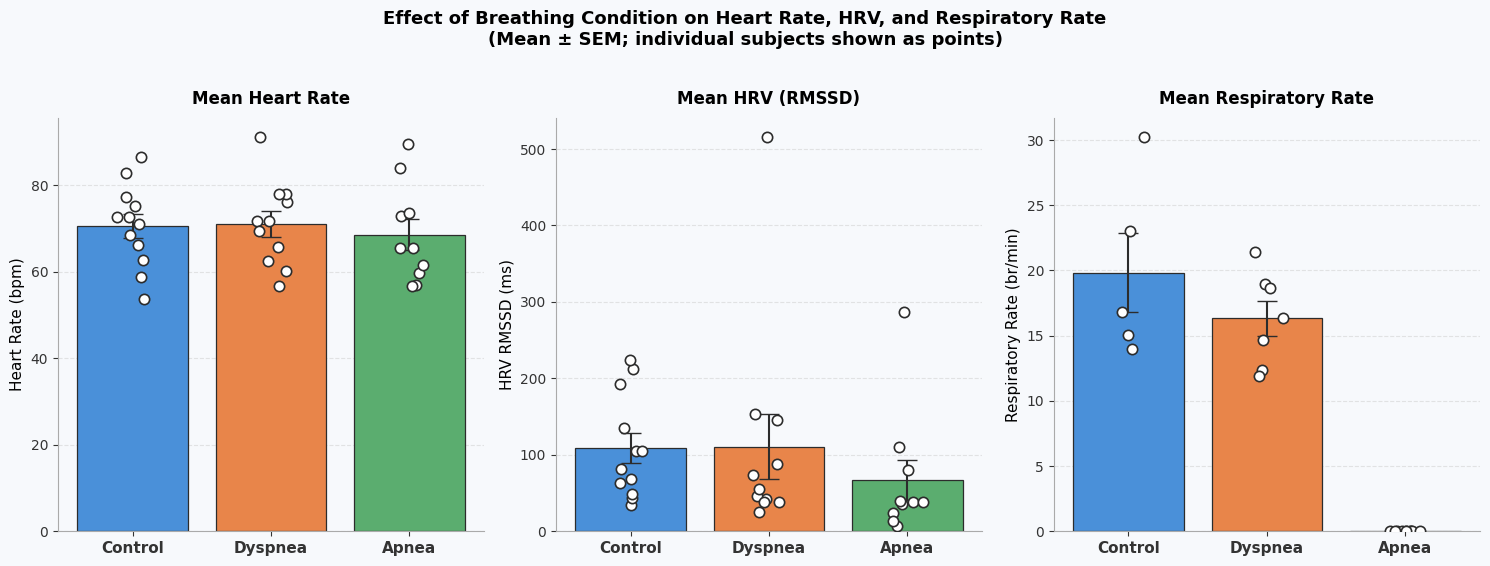

Figure saved

PEARSON CORRELATION: RSP Rate vs HR & HRV

RSP Rate vs Heart Rate
r = 0.021,  p = 0.9278  (not significant)
Line of best fit: y = 0.022x + 70.558
R² = 0.000

RSP Rate vs HRV (RMSSD)
r = 0.306,  p = 0.1768  (not significant)
Line of best fit: y = 2.321x + 56.052
R² = 0.094


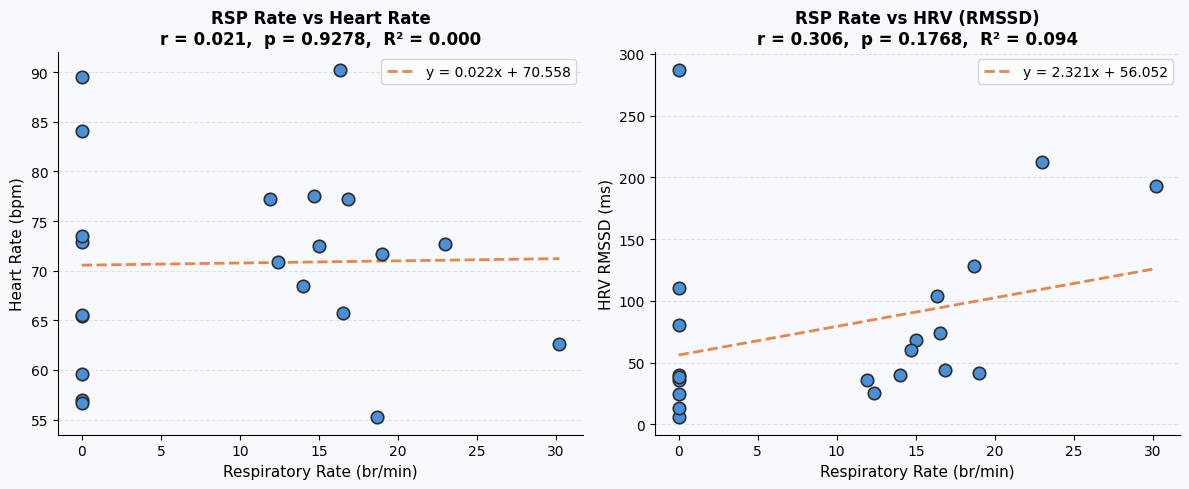


PER-SUBJECT ANALYSIS

ALEX
  control    HR=71.0  HRV=34.3  RSP=14.0
  dyspnea    HR=71.8  HRV=25.5  RSP=12.4
  apnea      HR=nan  HRV=nan  RSP=nan
  HRV drop (control→apnea): 34.3 ms  ← hypothesis score

ARTHUR
  control    HR=77.2  HRV=43.8  RSP=16.8
  dyspnea    HR=76.2  HRV=38.3  RSP=11.9
  apnea      HR=nan  HRV=nan  RSP=0.0
  HRV drop (control→apnea): 43.8 ms  ← hypothesis score

BEN
  control    HR=82.8  HRV=62.9  RSP=nan
  dyspnea    HR=91.0  HRV=87.7  RSP=16.4
  apnea      HR=84.0  HRV=35.8  RSP=0.0
  HRV drop (control→apnea): 27.1 ms  ← hypothesis score

CRYSTAL
  control    HR=72.7  HRV=212.3  RSP=23.0
  dyspnea    HR=62.5  HRV=515.2  RSP=nan
  apnea      HR=72.9  HRV=110.5  RSP=0.0
  HRV drop (control→apnea): 101.8 ms  ← hypothesis score

JENNY
  control    HR=62.6  HRV=192.9  RSP=30.2
  dyspnea    HR=65.7  HRV=73.9  RSP=21.4
  apnea      HR=65.3  HRV=6.4  RSP=0.0
  HRV drop (control→apnea): 186.5 ms  ← hypothesis score

JONAH
  control    HR=75.1  HRV=104.5  RSP=nan
  dysp

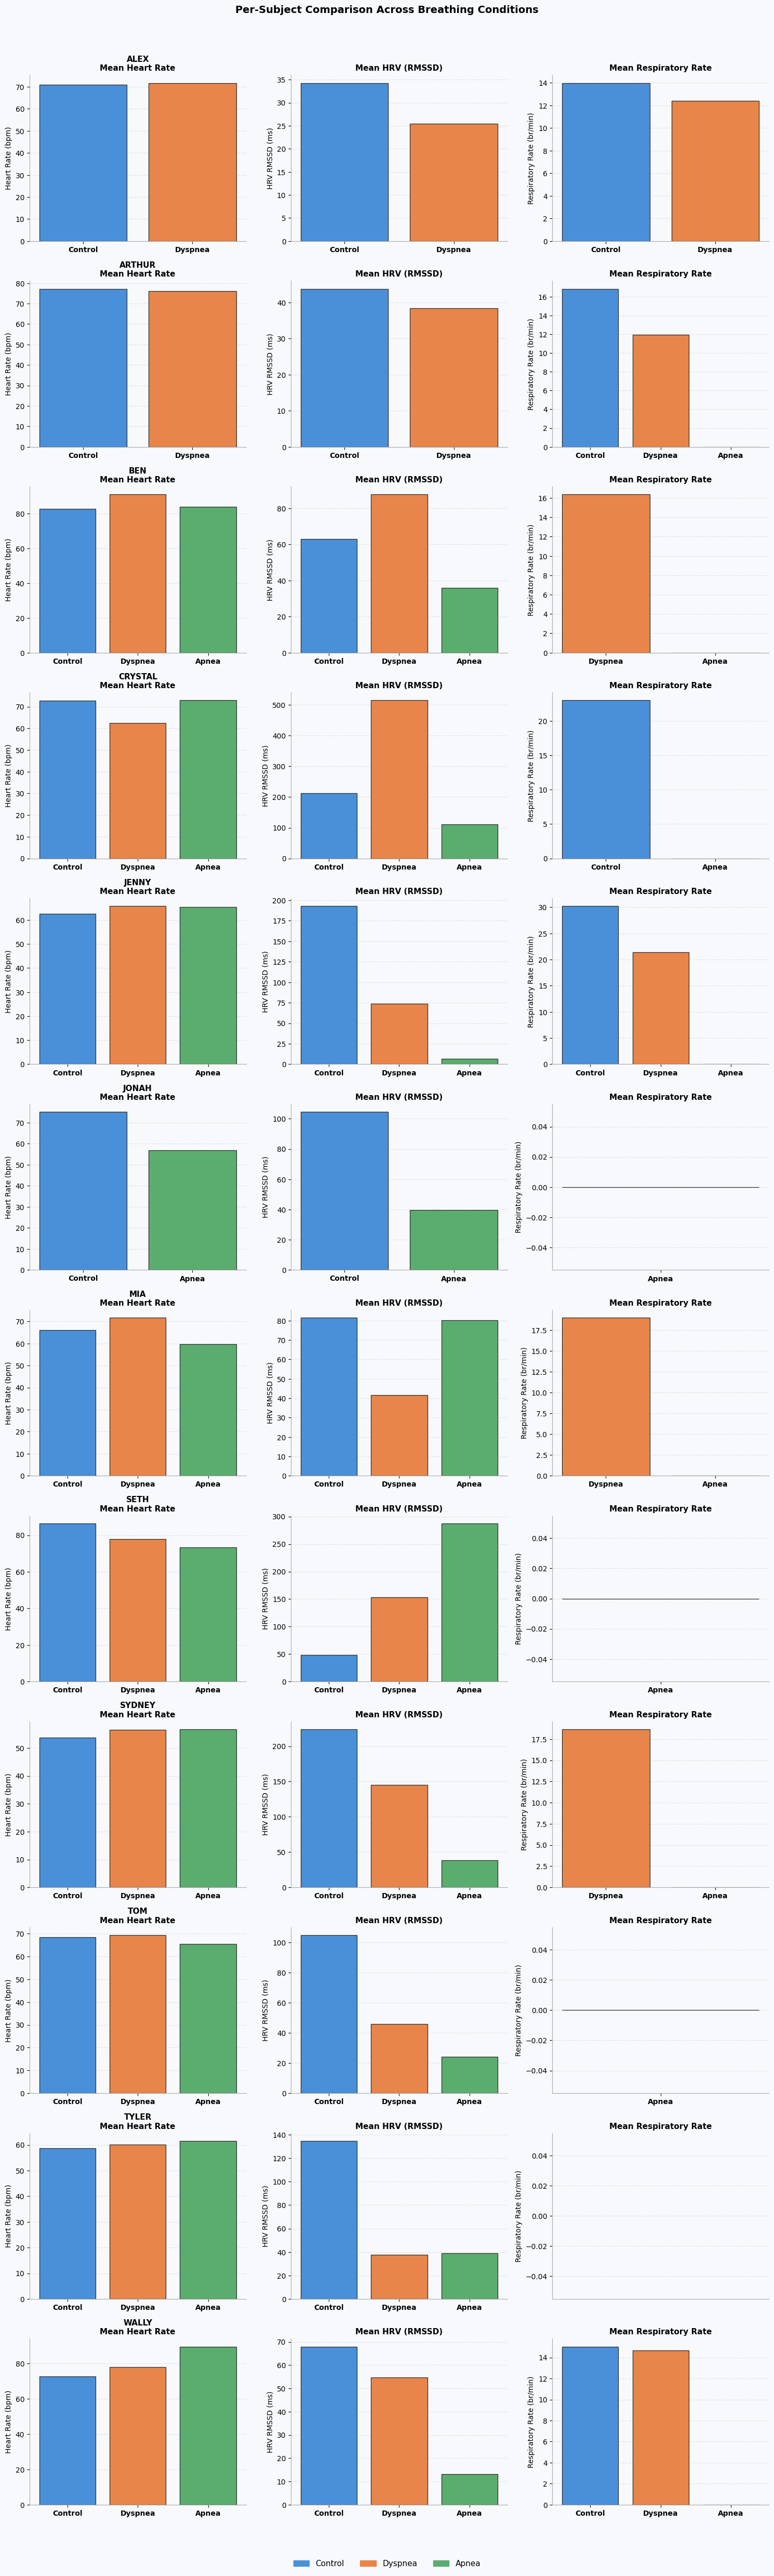

Per-subject figure saved


In [ ]:
# Move the trials to your drive folder since it doenst work from a shared folder then change DRIVE_FOLDER path to the folders path you placed the files in
# after that you should be able to run the program and it should work the way it should. There is one way anova, tukey test, pearson correlation test

!pip install neurokit2 -q

from google.colab import drive
drive.mount('/content/drive/')

import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import neurokit2 as nk
from scipy.stats import f_oneway, tukey_hsd

warnings.filterwarnings('ignore')

DRIVE_FOLDER = '/content/drive/MyDrive/test/'
SAMPLING_RATE = 200
CONDITIONS = ['control', 'dyspnea', 'apnea']
TRIALS = ['1', '2', '3']

def parse_filename(path):

    stem = os.path.splitext(os.path.basename(path))[0].lower()
    parts = stem.split('_')
    suffix = parts[-1].upper()
    trial = parts[-2]
    condition = parts[0].lower()
    subject = '_'.join(parts[1:-2])
    return condition, subject, trial, suffix

def process_ecg(path):

    try:
        df = pd.read_csv(path, sep='\t')
        ecg = df['ECG'].dropna().to_numpy(dtype=float)
        ecg = ecg[2000:]

        signals, info = nk.ecg_process(ecg, sampling_rate=SAMPLING_RATE)

        hr = float(np.nanmean(signals['ECG_Rate'].to_numpy()))

        r_peaks = info['ECG_R_Peaks']
        rr_ms = np.diff(r_peaks) / SAMPLING_RATE * 1000.0
        rmssd = float(np.sqrt(np.mean(np.diff(rr_ms) ** 2))) if len(rr_ms) > 1 else np.nan

        return hr, rmssd

    except Exception as e:
        print(f'ECG ERROR: {e}')
        return np.nan, np.nan

def process_lung(path):

    try:
        df = pd.read_csv(path, sep='\t')
        airflow = df['Air Flow'].dropna().to_numpy(dtype=float)
        airflow = airflow[2000:]

        signals, _ = nk.rsp_process(airflow, sampling_rate=SAMPLING_RATE)
        rsp_rate = float(np.nanmean(signals['RSP_Rate'].to_numpy()))
        return rsp_rate

    except Exception as e:
        print(f'LUNG ERROR: {e}')
        return np.nan

ecg_glob = glob.glob(f'{DRIVE_FOLDER}*_HR.xls') + glob.glob(f'{DRIVE_FOLDER}*_hr.xls')
lung_glob = glob.glob(f'{DRIVE_FOLDER}*_S.xls') + glob.glob(f'{DRIVE_FOLDER}*_s.xls')

print(f'Found {len(ecg_glob)} ECG files and {len(lung_glob)} lung files.\n')

ecg_raw = {}
lung_raw = {}
for f in sorted(ecg_glob):
    cond, subj, trial, _ = parse_filename(f)
    ecg_raw[(cond, subj, trial)] = process_ecg(f)

for f in sorted(lung_glob):
    cond, subj, trial, _ = parse_filename(f)

    if cond == 'apnea':
      lung_raw[(cond, subj, trial)] = 0
    else:
      lung_raw[(cond, subj, trial)] = process_lung(f)

subjects = sorted(set(subj for (_, subj, _) in ecg_raw))
print(f'Subjects detected: {subjects}')

summary = {c: {'HR': [], 'HRV_RMSSD': [], 'RSP_Rate': []} for c in CONDITIONS}

for cond in CONDITIONS:
    for subj in subjects:
        hrs, rmssds, rsps = [], [], []
        for trial in TRIALS:
            key = (cond, subj, trial)
            if key in ecg_raw:
                h, r = ecg_raw[key]
                if not np.isnan(h):
                    hrs.append(h)
                if not np.isnan(r):
                    rmssds.append(r)
            if key in lung_raw:
                rsp = lung_raw[key]
                if not np.isnan(rsp):
                    rsps.append(rsp)

        if hrs:
            summary[cond]['HR'].append(np.mean(hrs))
        if rmssds:
            summary[cond]['HRV_RMSSD'].append(np.mean(rmssds))
        if rsps:
            summary[cond]['RSP_Rate'].append(np.mean(rsps))

print('\nDESCRIPTIVE STATISTICS')

metric_labels = {'HR': 'Heart Rate (bpm)', 'HRV_RMSSD': 'HRV RMSSD (ms)', 'RSP_Rate': 'Resp. Rate (br/min)'}
for cond in CONDITIONS:
    print(f'\n{cond.upper()}')
    for metric, label in metric_labels.items():
        vals = summary[cond][metric]
        if vals:
            print(f'{label:<25s} mean={np.mean(vals):.2f}  SD={np.std(vals, ddof=1) if len(vals)>1 else 0:.2f}  n={len(vals)}')
        else:
            print(f'{label:<25s} no data')

print('\nSTATISTICAL TESTS')

for metric, label in metric_labels.items():
    groups = [summary[c][metric] for c in CONDITIONS if len(summary[c][metric]) >= 2]
    cond_labels = [c for c in CONDITIONS if len(summary[c][metric]) >= 2]
    print(f'\n{label}')
    if len(groups) >= 2:
        f_stat, p_val = f_oneway(*groups)
        sig = 'significant' if p_val < 0.05 else 'not significant'
        print(f'F = {f_stat:.3f}, p = {p_val:.4f} ({sig})')
        if p_val < 0.05 and len(groups) >= 3:
            result = tukey_hsd(*groups)
            print('Tukey HSD pairwise p-values:')
            for i, ci in enumerate(cond_labels):
                for j, cj in enumerate(cond_labels):
                    if j > i:
                        pv = result.pvalue[i, j]
                        print(f'{ci} vs {cj}: p = {pv:.4f}')
    else:
        print('Not enough groups for ANOVA.')

COLORS = {'control': '#4A90D9', 'dyspnea': '#E8854A', 'apnea': '#5BAD6F'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.patch.set_facecolor('#F7F9FC')

metrics_plot = [
    ('HR', 'Heart Rate (bpm)', 'Mean Heart Rate'),
    ('HRV_RMSSD', 'HRV RMSSD (ms)', 'Mean HRV (RMSSD)'),
    ('RSP_Rate', 'Respiratory Rate (br/min)', 'Mean Respiratory Rate'),
]

for ax, (metric, ylabel, title) in zip(axes, metrics_plot):
    ax.set_facecolor('#F7F9FC')
    means = []
    sems = []
    colors = []
    valid_conds = []

    for cond in CONDITIONS:
        vals = summary[cond][metric]
        if vals:
            means.append(np.mean(vals))
            sems.append(np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0)
            colors.append(COLORS[cond])
            valid_conds.append(cond.capitalize())

    x = np.arange(len(valid_conds))
    bars = ax.bar(x, means, yerr=sems, capsize=7,
                  color=colors, edgecolor='#2C2C2C', linewidth=0.9,
                  error_kw=dict(elinewidth=1.5, ecolor='#2C2C2C'))

    for i, cond in enumerate(CONDITIONS):
        if cond not in [c.lower() for c in valid_conds]:
            continue
        xi = [c.lower() for c in valid_conds].index(cond)
        vals = summary[cond][metric]
        jitter = np.random.uniform(-0.12, 0.12, len(vals))
        ax.scatter(xi + jitter, vals, color='white', edgecolors='#2C2C2C',
                   s=55, zorder=5, linewidth=1.2)

    ax.set_xticks(x)
    ax.set_xticklabels(valid_conds, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#AAAAAA')
    ax.tick_params(colors='#333333')
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')
    ax.set_axisbelow(True)

fig.suptitle(
    'Effect of Breathing Condition on Heart Rate, HRV, and Respiratory Rate\n'
    '(Mean ± SEM; individual subjects shown as points)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('breathing_conditions_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved')

# Correlation: Respiratory Rate vs HR and HRV

from scipy.stats import pearsonr

print("\nPEARSON CORRELATION: RSP Rate vs HR & HRV")

rsp_all, hr_all, hrv_all = [], [], []

for cond in CONDITIONS:
    for subj in subjects:
        rsp_vals, hr_vals, hrv_vals = [], [], []
        for trial in TRIALS:
            key = (cond, subj, trial)
            if key in lung_raw and key in ecg_raw:
                rsp = lung_raw[key]
                hr, hrv = ecg_raw[key]
                if not np.isnan(rsp) and not np.isnan(hr):
                    rsp_vals.append(rsp)
                    hr_vals.append(hr)
                if not np.isnan(rsp) and not np.isnan(hrv):
                    hrv_vals.append(hrv)
        if rsp_vals:
            rsp_all.append(np.mean(rsp_vals))
            hr_all.append(np.mean(hr_vals))
        if hrv_vals:
            hrv_all.append(np.mean(hrv_vals))

if len(rsp_all) >= 3:
    r, p = pearsonr(rsp_all, hr_all)
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    m_hr, b_hr = np.polyfit(rsp_all, hr_all, 1)
    r2_hr = r ** 2
    print(f"\nRSP Rate vs Heart Rate")
    print(f"r = {r:.3f},  p = {p:.4f}  ({sig})")
    print(f"Line of best fit: y = {m_hr:.3f}x + {b_hr:.3f}")
    print(f"R² = {r2_hr:.3f}")

if len(rsp_all) >= 3:
    r, p = pearsonr(rsp_all, hrv_all)
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    m_hrv, b_hrv = np.polyfit(rsp_all, hrv_all, 1)
    r2_hrv = r ** 2
    print(f"\nRSP Rate vs HRV (RMSSD)")
    print(f"r = {r:.3f},  p = {p:.4f}  ({sig})")
    print(f"Line of best fit: y = {m_hrv:.3f}x + {b_hrv:.3f}")
    print(f"R² = {r2_hrv:.3f}")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#F7F9FC')

for ax, y_vals, ylabel, title in zip(
    axes,
    [hr_all, hrv_all],
    ['Heart Rate (bpm)', 'HRV RMSSD (ms)'],
    ['RSP Rate vs Heart Rate', 'RSP Rate vs HRV (RMSSD)']
):
    ax.set_facecolor('#F7F9FC')
    ax.scatter(rsp_all, y_vals, color='#4A90D9', edgecolors='#2C2C2C',
               s=80, zorder=5, linewidth=1.2)

    m, b = np.polyfit(rsp_all, y_vals, 1)
    x_line = np.linspace(min(rsp_all), max(rsp_all), 100)
    sign = '+' if b >= 0 else '-'
    eq_label = f'y = {m:.3f}x {sign} {abs(b):.3f}'
    ax.plot(x_line, m * x_line + b, color='#E8854A', linewidth=2, linestyle='--',
            label=eq_label)

    r, p = pearsonr(rsp_all, y_vals)
    r2 = r ** 2
    ax.legend(loc='best', fontsize=10, frameon=True)
    ax.set_xlabel('Respiratory Rate (br/min)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{title}\nr = {r:.3f},  p = {p:.4f},  R² = {r2:.3f}',
                 fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('correlation_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-subject analysis ─────────────────────────────────────
print('\nPER-SUBJECT ANALYSIS')

subject_scores = {}

for subj in subjects:
    print(f'\n{subj.upper()}')
    subj_rsp, subj_hr, subj_hrv = [], [], []

    for cond in CONDITIONS:
        hrs, rmssds, rsps = [], [], []
        for trial in TRIALS:
            key = (cond, subj, trial)
            if key in ecg_raw:
                h, r = ecg_raw[key]
                if not np.isnan(h): hrs.append(h)
                if not np.isnan(r): rmssds.append(r)
            if key in lung_raw:
                rsp = lung_raw[key]
                if not np.isnan(rsp): rsps.append(rsp)

        hr_mean  = np.mean(hrs)    if hrs    else np.nan
        hrv_mean = np.mean(rmssds) if rmssds else np.nan
        rsp_mean = np.mean(rsps)   if rsps   else np.nan

        print(f'  {cond:<10s} HR={hr_mean:.1f}  HRV={hrv_mean:.1f}  RSP={rsp_mean:.1f}')

        if not np.isnan(rsp_mean): subj_rsp.append(rsp_mean)
        if not np.isnan(hr_mean):  subj_hr.append(hr_mean)
        if not np.isnan(hrv_mean): subj_hrv.append(hrv_mean)

    # Score: hypothesis predicts apnea lowers HRV vs control
    # Higher score = better match to hypothesis
    try:
        hrv_by_cond = {}
        for cond in CONDITIONS:
            vals = []
            for trial in TRIALS:
                key = (cond, subj, trial)
                if key in ecg_raw:
                    _, r = ecg_raw[key]
                    if not np.isnan(r): vals.append(r)
            if vals: hrv_by_cond[cond] = np.mean(vals)

        # Hypothesis: control HRV > apnea HRV, dyspnea HRV between
        hrv_drop = hrv_by_cond.get('control', 0) - hrv_by_cond.get('apnea', 0)
        subject_scores[subj] = hrv_drop
        print(f'  HRV drop (control→apnea): {hrv_drop:.1f} ms  ← hypothesis score')
    except:
        subject_scores[subj] = 0

# Best subject for hypothesis
best_subj = max(subject_scores, key=subject_scores.get)
print(f'\nMOST OPTIMAL SUBJECT FOR HYPOTHESIS: {best_subj.upper()}')
print(f'  HRV dropped {subject_scores[best_subj]:.1f} ms from control to apnea')
print(f'  (largest drop = strongest match to hypothesis that apnea reduces HRV)')

# ── Per-subject figure ───────────────────────────────────────
fig, axes = plt.subplots(len(subjects), 3, figsize=(15, 4 * len(subjects)))
fig.patch.set_facecolor('#F7F9FC')

for row, subj in enumerate(subjects):
    for col, (metric, ylabel, title) in enumerate(metrics_plot):
        ax = axes[row, col] if len(subjects) > 1 else axes[col]
        ax.set_facecolor('#F7F9FC')

        vals_by_cond = []
        colors = []
        cond_names = []

        for cond in CONDITIONS:
            trial_vals = []
            for trial in TRIALS:
                key = (cond, subj, trial)
                if metric == 'RSP_Rate' and key in lung_raw:
                    v = lung_raw[key]
                    if not np.isnan(v): trial_vals.append(v)
                elif metric in ('HR', 'HRV_RMSSD') and key in ecg_raw:
                    h, r = ecg_raw[key]
                    v = h if metric == 'HR' else r
                    if not np.isnan(v): trial_vals.append(v)

            if trial_vals:
                vals_by_cond.append(np.mean(trial_vals))
                colors.append(COLORS[cond])
                cond_names.append(cond.capitalize())

        x = np.arange(len(cond_names))
        ax.bar(x, vals_by_cond, color=colors, edgecolor='#2C2C2C',
               linewidth=0.9)
        ax.set_xticks(x)
        ax.set_xticklabels(cond_names, fontsize=10, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=10)
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines[['left', 'bottom']].set_color('#AAAAAA')
        ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')
        ax.set_axisbelow(True)

        if col == 0:
            ax.set_title(f'{subj.upper()}\n{title}', fontsize=11, fontweight='bold')
        else:
            ax.set_title(title, fontsize=11, fontweight='bold')

# Legend
legend_patches = [mpatches.Patch(color=COLORS[c], label=c.capitalize()) for c in CONDITIONS]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Per-Subject Comparison Across Breathing Conditions',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('per_subject_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Per-subject figure saved')